# Selección de estaciones y construcción del panel de ozono

## Tópicos Selectos de Matemáticas Aplicadas II

En este notebook construiremos un conjunto de datos analítico a partir de las concentraciones horarias de ozono registradas por distintas estaciones de monitoreo.

En el notebook anterior estudiamos la estructura temporal de la base y encontramos que:

- las observaciones presentan frecuencia horaria regular;
- los valores `-99` representan mediciones faltantes;
- existen diferencias importantes en la cobertura entre estaciones;
- algunas estaciones no presentan ninguna observación válida;
- existen huecos temporales de diferente duración;
- también aparecen episodios en los que varias estaciones dejan de reportar simultáneamente.

El objetivo ahora será utilizar esta información para construir un **panel de estaciones suficientemente completo y adecuado para análisis posteriores**.



## Objetivos

Durante este notebook realizaremos las siguientes etapas:

1. cargar y preparar nuevamente los datos originales;
2. calcular la cobertura temporal de cada estación;
3. estudiar la continuidad de las mediciones;
4. seleccionar las estaciones que cumplen los criterios de calidad establecidos;
5. visualizar la cobertura y los patrones temporales de las estaciones seleccionadas;
6. realizar un análisis descriptivo de las concentraciones de ozono;
7. transformar los datos de formato ancho a formato largo;
8. verificar la estructura estación--tiempo;
9. construir el panel analítico final.

El flujo general será

$$
\boxed{
\text{datos originales}
\rightarrow
\text{control de calidad}
\rightarrow
\text{selección de estaciones}
\rightarrow
\text{análisis exploratorio}
\rightarrow
\text{panel final}
}
$$


## Criterio inicial de selección

Como primer criterio utilizaremos la cobertura temporal.

Si $C_i$ representa el porcentaje de observaciones disponibles de la estación $i$, consideraremos inicialmente

$$
C_i\geq 90\%.
$$

Sin embargo, la cobertura no será el único elemento que examinaremos.

También estudiaremos la longitud de los huecos consecutivos, ya que una estación puede tener una cobertura global alta y aun así presentar interrupciones prolongadas.

Por tanto, distinguiremos entre

$$
\text{cantidad de información}
$$

y

$$
\text{continuidad de la información}.
$$

La selección definitiva de estaciones se realizará después de analizar ambos aspectos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
url = "https://github.com/jamc88/TSMA-II-26-O/raw/refs/heads/main/Datos/2026O3.xls"

df_raw = pd.read_excel(url)

print("Dimensiones del dataset:")
print(df_raw.shape)

df_raw.head()

Dimensiones del dataset:
(1416, 38)


,FECHA,HORA,ACO,AJM,AJU,ATI,BJU,CAM,CCA,CHO,...,SAG,SFE,SJA,TAH,TLA,TLI,UAX,UIZ,VIF,XAL
0,2026-01-01,1,-99,19,-99,18,17,4,13,-99,...,19,-99,-99,-99,5,10,23,14,4,4
1,2026-01-01,2,-99,23,-99,11,14,5,9,-99,...,5,-99,-99,-99,6,6,11,5,7,5
2,2026-01-01,3,-99,30,-99,13,5,5,10,-99,...,3,-99,-99,-99,7,6,1,2,9,4
3,2026-01-01,4,-99,34,-99,8,4,3,8,-99,...,3,-99,-99,-99,5,6,2,3,9,5
4,2026-01-01,5,-99,36,-99,4,5,3,5,-99,...,3,-99,-99,-99,8,8,2,3,8,5


In [3]:
print("Dimensiones:")
print(df_raw.shape)

print("\nPeriodo reportado en la columna FECHA:")
print(df_raw["FECHA"].min(), "a", df_raw["FECHA"].max())

print("\nNúmero de columnas correspondientes a estaciones:")
print(df_raw.shape[1] - 2)

Dimensiones:
(1416, 38)

Periodo reportado en la columna FECHA:
2026-01-01 00:00:00 a 2026-02-28 00:00:00

Número de columnas correspondientes a estaciones:
36


## Preparación de la base temporal

In [4]:
estaciones = [
    col for col in df_raw.columns
    if col not in ["FECHA", "HORA"]
]

print("Número de estaciones:")
print(len(estaciones))


df = df_raw.copy()

# Sustitución de -99 por NaN

df[estaciones] = df[estaciones].replace(-99, np.nan)

# Construcción del timestamp

df["FECHA"] = pd.to_datetime(df["FECHA"],errors="coerce")

df["timestamp"] = df["FECHA"] + pd.to_timedelta(df["HORA"],unit="h")

# Orden cronológico
df = df.sort_values("timestamp").reset_index(drop=True)

# Construcción de la matriz temporal

o3_horario = df.set_index("timestamp")[estaciones].sort_index()


print("\nPrimer instante:")
print(o3_horario.index.min())

print("\nÚltimo instante:")
print(o3_horario.index.max())

print("\nNúmero de instantes horarios:")
print(len(o3_horario))

print("\nTimestamps duplicados:")
print(o3_horario.index.duplicated().sum())

print("\nFrecuencia inferida:")
print(pd.infer_freq(o3_horario.index))


# Diferencias entre instantes consecutivos
delta_t = o3_horario.index.to_series().diff()

porcentaje_horario = (
    (delta_t.dropna() == pd.Timedelta(hours=1))
    .mean() * 100
)

print("\nPorcentaje de intervalos de exactamente 1 hora:")
print(f"{porcentaje_horario:.2f}%")

# valores faltantes

print("\nNúmero total de valores faltantes:")
print(o3_horario.isna().sum().sum())

print("\nPorcentaje global de valores faltantes:")
print(f"{100 * o3_horario.isna().mean().mean():.2f}%")

Número de estaciones:
36

Primer instante:
2026-01-01 01:00:00

Último instante:
2026-03-01 00:00:00

Número de instantes horarios:
1416

Timestamps duplicados:
0

Frecuencia inferida:
h

Porcentaje de intervalos de exactamente 1 hora:
100.00%

Número total de valores faltantes:
18316

Porcentaje global de valores faltantes:
35.93%


## Diagnóstico de calidad por estación

In [5]:
# Función para resumir huecos consecutivos

def resumen_huecos(serie):

    faltante = serie.isna()

    n_faltantes = int(faltante.sum())

    # Caso sin valores faltantes
    if n_faltantes == 0:
        return pd.Series({
            "n_faltantes": 0,
            "n_huecos": 0,
            "hueco_max_horas": 0
        })

    # Identificación de bloques consecutivos
    grupos = faltante.ne(faltante.shift()).cumsum()

    # Longitud de los bloques correspondientes a NaN
    longitudes = (
        faltante[faltante]
        .groupby(grupos[faltante])
        .size()
    )

    return pd.Series({
        "n_faltantes": n_faltantes,
        "n_huecos": int(len(longitudes)),
        "hueco_max_horas": int(longitudes.max())
    })

In [6]:
# Diagnóstico por estación

T = len(o3_horario)

diagnostico = pd.DataFrame({
    estacion: resumen_huecos(
        o3_horario[estacion]
    )
    for estacion in estaciones
}).T


# Número de observaciones válidas
diagnostico["n_disponibles"] = o3_horario.notna().sum()


# Número esperado
diagnostico["n_esperadas"] = T


# Cobertura
diagnostico["cobertura_pct"] = (
    diagnostico["n_disponibles"]
    / diagnostico["n_esperadas"]
    * 100
)


# Hueco máximo expresado en días
diagnostico["hueco_max_dias"] = (
    diagnostico["hueco_max_horas"] / 24
)


# Reordenamos columnas
diagnostico = diagnostico[
    [
        "n_esperadas",
        "n_disponibles",
        "n_faltantes",
        "cobertura_pct",
        "n_huecos",
        "hueco_max_horas",
        "hueco_max_dias"
    ]
]


# Ordenamos de mayor a menor cobertura
diagnostico = diagnostico.sort_values("cobertura_pct",ascending=False)


print("Diagnóstico de calidad por estación:")

display(diagnostico.round(2))


print("\nResumen de cobertura:")

display(
    diagnostico["cobertura_pct"]
    .describe().round(2).to_frame("cobertura_pct")
)

Diagnóstico de calidad por estación:


,n_esperadas,n_disponibles,n_faltantes,cobertura_pct,n_huecos,hueco_max_horas,hueco_max_dias
PED,1416,1379,37,97.39,10,11,0.46
MGH,1416,1379,37,97.39,11,4,0.17
HGM,1416,1378,38,97.32,13,5,0.21
FAC,1416,1378,38,97.32,14,4,0.17
UIZ,1416,1371,45,96.82,18,5,0.21
AJM,1416,1367,49,96.54,17,10,0.42
ATI,1416,1364,52,96.33,17,7,0.29
LLA,1416,1364,52,96.33,12,23,0.96
UAX,1416,1355,61,95.69,11,30,1.25
CUT,1416,1347,69,95.13,7,52,2.17



Resumen de cobertura:


,cobertura_pct
count,36.00
mean,64.07
std,40.06
min,0.00
25%,28.39
50%,86.97
75%,95.27
max,97.39


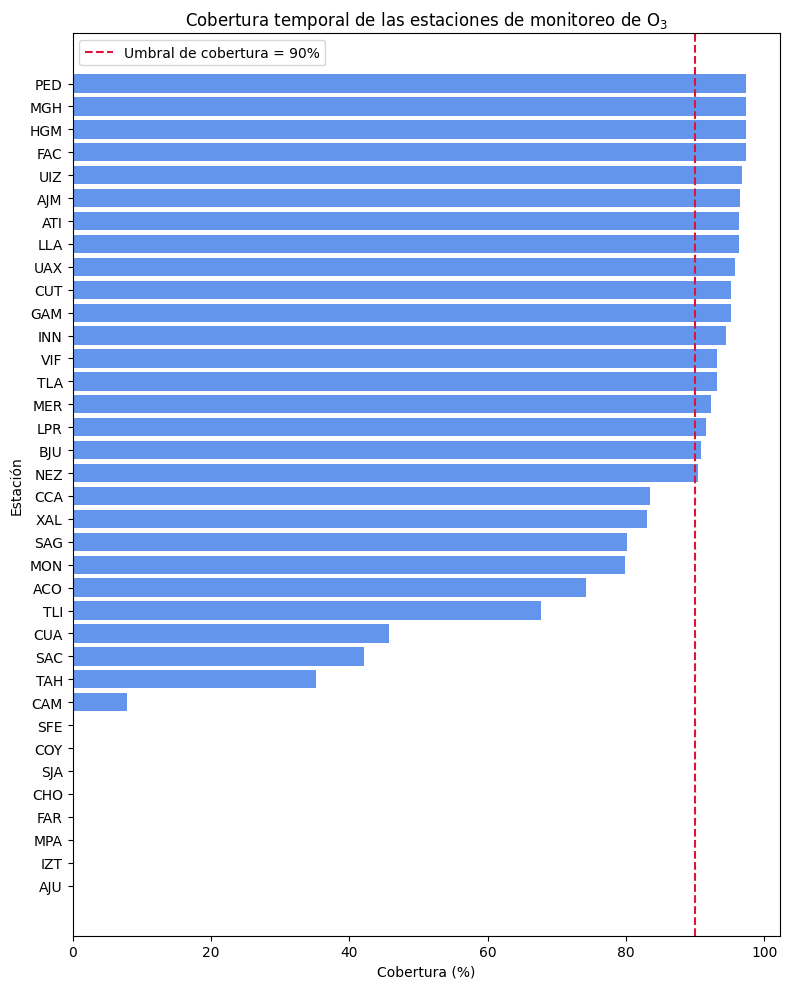

Estaciones con cobertura >= 90%: 18 de 36


In [7]:
# Visualización de la cobertura por estación

cobertura_ordenada = (
    diagnostico["cobertura_pct"]
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 10)) 

ax.barh(
    cobertura_ordenada.index,
    cobertura_ordenada.values, color='cornflowerblue'
)

ax.axvline(x=90, linestyle="--", linewidth=1.5,
    label="Umbral de cobertura = 90%", color='crimson'
)

ax.set_title("Cobertura temporal de las estaciones de monitoreo de O$_3$")

ax.set_xlabel("Cobertura (%)")
ax.set_ylabel("Estación")


ax.legend()
plt.tight_layout()
plt.savefig("cobertura_estaciones.png", dpi=200)
plt.show()

# Número de estaciones que cumplen el criterio
n_seleccionadas = (diagnostico["cobertura_pct"] >= 90).sum()

print(f"Estaciones con cobertura >= 90%: "
    f"{n_seleccionadas} de {len(diagnostico)}")

## Cobertura y continuidad temporal

La cobertura indica qué proporción de observaciones está disponible, pero no describe cómo se distribuyen los valores faltantes en el tiempo.

Por ello analizaremos simultáneamente dos indicadores:

- cobertura temporal $C_i$;
- duración del hueco máximo $G_i$.

Cada estación será representada mediante el punto

$$
(C_i,G_i).
$$

Una estación ideal tendría:

$$
C_i \approx 100\%
$$

y

$$
G_i \approx 0.
$$

En cambio, una estación puede tener cobertura superior al $90\%$ y aun así presentar una interrupción prolongada.

Para este ejercicio utilizaremos inicialmente dos referencias:

$$
C_i \geq 90\%
$$

y un hueco máximo de

$$
G_i \leq 48\text{ horas},
$$

equivalente a dos días consecutivos sin información.

El segundo umbral se utilizará como criterio exploratorio para distinguir entre interrupciones relativamente cortas y huecos prolongados.

La selección final deberá considerar conjuntamente ambos indicadores y no únicamente el porcentaje de cobertura.

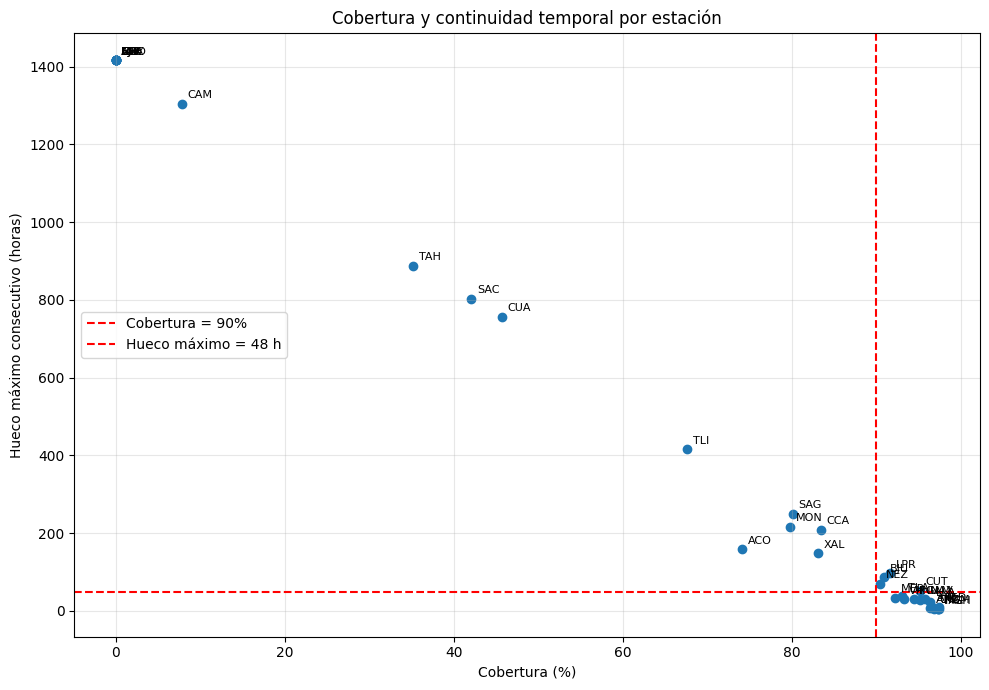

In [8]:
# Cobertura vs. hueco temporal máximo

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    diagnostico["cobertura_pct"],
    diagnostico["hueco_max_horas"]
)

# Etiquetas de estaciones
for estacion, fila in diagnostico.iterrows():
    ax.annotate(
        estacion,
        (
            fila["cobertura_pct"],
            fila["hueco_max_horas"]
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )


ax.axvline(
    90,
    linestyle="--",
    linewidth=1.5,
    label="Cobertura = 90%", color ='red'
)

ax.axhline(
    48,
    linestyle="--",
    linewidth=1.5,
    label="Hueco máximo = 48 h", color ='red'
)


ax.set_title(
    "Cobertura y continuidad temporal por estación"
)

ax.set_xlabel("Cobertura (%)")
ax.set_ylabel("Hueco máximo consecutivo (horas)")

ax.legend()

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Estaciones que cumplen ambos criterios

criterio_cobertura = (
    diagnostico["cobertura_pct"] >= 90
)

criterio_hueco = (
    diagnostico["hueco_max_horas"] <= 48
)

candidatas = diagnostico[
    criterio_cobertura & criterio_hueco].copy()


print("Estaciones que cumplen ambos criterios:")
print(candidatas.index.tolist())

print("\nNúmero de estaciones:")
print(len(candidatas))

display(
    candidatas[
        [
            "cobertura_pct",
            "n_faltantes",
            "n_huecos",
            "hueco_max_horas",
            "hueco_max_dias"
        ]
    ].round(2)
)

Estaciones que cumplen ambos criterios:
['PED', 'MGH', 'HGM', 'FAC', 'UIZ', 'AJM', 'ATI', 'LLA', 'UAX', 'GAM', 'INN', 'VIF', 'TLA', 'MER']

Número de estaciones:
14


,cobertura_pct,n_faltantes,n_huecos,hueco_max_horas,hueco_max_dias
PED,97.39,37,10,11,0.46
MGH,97.39,37,11,4,0.17
HGM,97.32,38,13,5,0.21
FAC,97.32,38,14,4,0.17
UIZ,96.82,45,18,5,0.21
AJM,96.54,49,17,10,0.42
ATI,96.33,52,17,7,0.29
LLA,96.33,52,12,23,0.96
UAX,95.69,61,11,30,1.25
GAM,95.13,69,17,28,1.17


## 6. Selección definitiva de estaciones y disponibilidad del panel

A partir de los dos criterios establecidos,

$$
C_i \geq 90\%
$$

y

$$
G_i \leq 48\text{ horas},
$$

se seleccionaron $14$ estaciones:

$$
\mathcal{S}^{\ast}
=
\{
\text{PED, MGH, HGM, FAC, UIZ, AJM, ATI, LLA, UAX, GAM, INN, VIF, TLA, MER}
\}.
$$

Estas estaciones presentan simultáneamente:

- alta cobertura temporal;
- ausencia de interrupciones superiores a dos días consecutivos.

A partir de este punto trabajaremos únicamente con este subconjunto, sin modificar la base original.

Construiremos la matriz

$$
\mathbf{X}^{\ast}
=
\left(X_{i,t}\right),
$$

con

$$
T=1416
$$

instantes horarios y

$$
N=14
$$

estaciones.

Por tanto, la matriz analítica en formato ancho tendrá dimensión

$$
1416\times14.
$$

Antes de analizar las concentraciones de ozono, visualizaremos nuevamente la disponibilidad temporal de estas estaciones.

Definiremos

$$
A_{i,t}
=
\begin{cases}
1, & \text{si existe una medición válida},\\
0, & \text{si la medición está ausente}.
\end{cases}
$$

La finalidad es comprobar visualmente que, después de aplicar los criterios de selección, el panel presenta una estructura temporal suficientemente completa y que los valores faltantes restantes corresponden principalmente a interrupciones relativamente cortas.

In [10]:
# Construcción del panel en formato ancho

estaciones_finales = candidatas.index.tolist()

o3_seleccionado = o3_horario[estaciones_finales].copy()
o3_seleccionado

,PED,MGH,HGM,FAC,UIZ,AJM,ATI,LLA,UAX,GAM,INN,VIF,TLA,MER
timestamp,,,,,,,,,,,,,,
2026-01-01 01:00:00,4.0,18.0,12.0,19.0,14.0,19.0,18.0,6.0,23.0,2.0,9.0,4.0,5.0,7.0
2026-01-01 02:00:00,12.0,17.0,10.0,12.0,5.0,23.0,11.0,1.0,11.0,6.0,11.0,7.0,6.0,3.0
2026-01-01 03:00:00,15.0,8.0,4.0,9.0,2.0,30.0,13.0,1.0,1.0,4.0,12.0,9.0,7.0,3.0
2026-01-01 04:00:00,18.0,3.0,3.0,9.0,3.0,34.0,8.0,1.0,2.0,2.0,17.0,9.0,5.0,3.0
2026-01-01 05:00:00,20.0,2.0,3.0,7.0,3.0,36.0,4.0,0.0,2.0,3.0,22.0,8.0,8.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-28 20:00:00,39.0,32.0,38.0,36.0,NaN,42.0,29.0,39.0,42.0,31.0,33.0,28.0,35.0,31.0
2026-02-28 21:00:00,34.0,30.0,34.0,27.0,NaN,36.0,26.0,35.0,28.0,28.0,25.0,24.0,28.0,28.0
2026-02-28 22:00:00,27.0,21.0,29.0,10.0,NaN,23.0,21.0,31.0,19.0,20.0,20.0,18.0,17.0,21.0


In [11]:
# Faltantes después de la selección

n_total = o3_seleccionado.size
n_faltantes = o3_seleccionado.isna().sum().sum()

print("\nNúmero total de valores posibles:")
print(n_total)

print("\nNúmero total de valores faltantes:")
print(n_faltantes)

print("\nPorcentaje global de faltantes:")
print(
    f"{100 * n_faltantes / n_total:.2f}%"
)


Número total de valores posibles:
19824

Número total de valores faltantes:
860

Porcentaje global de faltantes:
4.34%


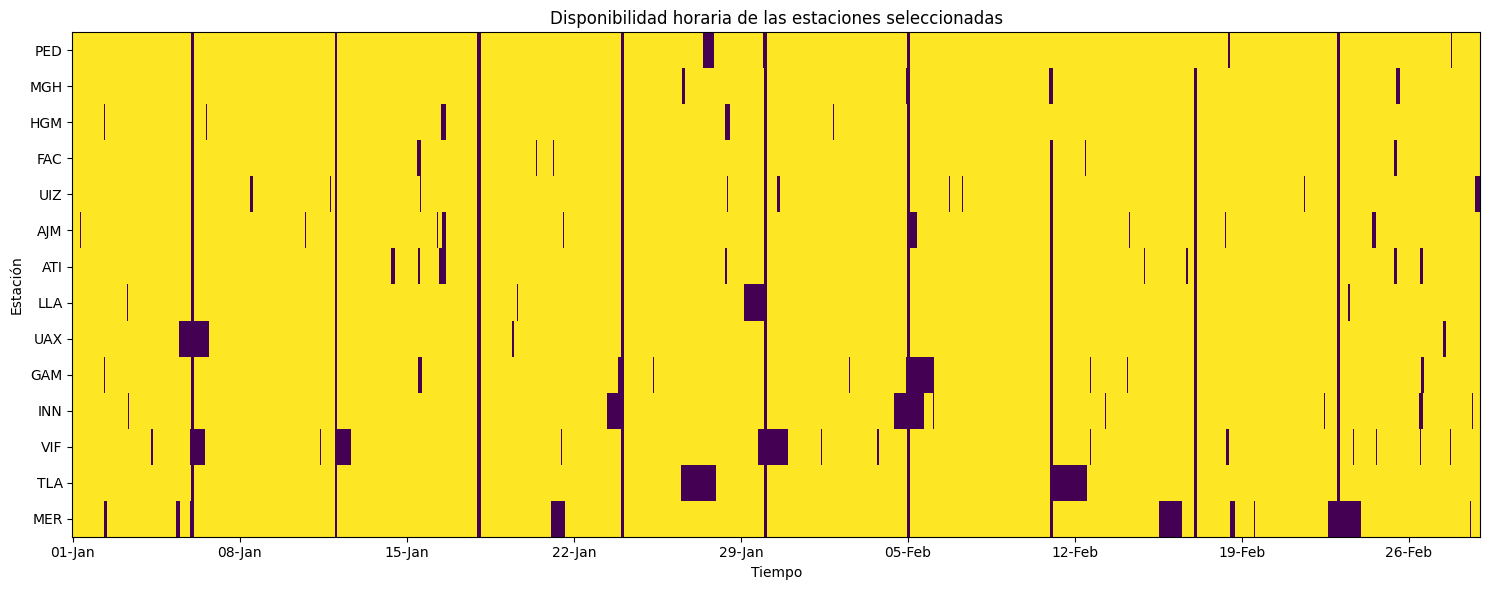

In [12]:
# Matriz de disponibilidad

matriz_disponibilidad = o3_seleccionado.notna().astype(int).T


fig, ax = plt.subplots(figsize=(15, 6))

ax.imshow(
    matriz_disponibilidad,
    aspect="auto",
    interpolation="nearest"
)

ax.set_title("Disponibilidad horaria de las estaciones seleccionadas")
ax.set_ylabel("Estación")
ax.set_xlabel("Tiempo")

ax.set_yticks(np.arange(len(estaciones_finales)))
ax.set_yticklabels(estaciones_finales)


paso = 24 * 7

posiciones = np.arange(0,len(o3_seleccionado),paso)
etiquetas = o3_seleccionado.index[posiciones].strftime("%d-%b")

ax.set_xticks(posiciones)
ax.set_xticklabels(etiquetas)

plt.tight_layout()
plt.show()

## Disponibilidad simultánea del panel seleccionado

Después de seleccionar las $14$ estaciones, el porcentaje global de valores faltantes disminuyó considerablemente: $4.34\%.$ Sin embargo, este porcentaje resume toda la matriz y no indica si los faltantes se encuentran distribuidos de manera independiente entre estaciones o si existen horas en las que varias estaciones dejan de reportar simultáneamente.

Para cada instante $t$ definiremos

$$
N_t=
\sum_{i=1}^{14}
I(X_{i,t}\text{ disponible}),
$$

donde $N_t$ representa el número de estaciones con una medición válida en la hora $t$.

El porcentaje de disponibilidad simultánea será

$$
P_t=
\frac{N_t}{14}\times100.
$$

Una hora completamente observada satisface

$$
N_t=14
\qquad\text{y}\qquad
P_t=100\%.
$$

En cambio, si

$$
N_t=0,
$$

ninguna de las estaciones seleccionadas dispone de información para esa hora.

Este análisis es importante antes de decidir cómo tratar los valores faltantes. Unos pocos valores aislados y una interrupción simultánea de toda la red representan problemas diferentes y no deberían tratarse automáticamente con el mismo procedimiento.

In [13]:
# Disponibilidad simultánea del panel seleccionado

disponibilidad_panel = pd.DataFrame(
    index=o3_seleccionado.index
)

disponibilidad_panel["n_disponibles"] = (
    o3_seleccionado.notna().sum(axis=1)
)

disponibilidad_panel["porcentaje_disponible"] = (
    disponibilidad_panel["n_disponibles"]
    / len(estaciones_finales) * 100
)


print("Resumen del número de estaciones disponibles por hora:")

display(disponibilidad_panel["n_disponibles"].describe().round(2).to_frame())


# Horas completamente observadas
n_completas = (
    disponibilidad_panel["n_disponibles"]
    == len(estaciones_finales)
).sum()

print("\nHoras con las 14 estaciones disponibles:")
print(n_completas)
print(f"Porcentaje: "f"{100 * n_completas / len(disponibilidad_panel):.2f}%")


# Horas sin ninguna estación disponible
n_sin_datos = (
    disponibilidad_panel["n_disponibles"] == 0
).sum()

print("\nHoras sin ninguna estación disponible:")
print(n_sin_datos)

print(f"Porcentaje: "f"{100 * n_sin_datos / len(disponibilidad_panel):.2f}%")


# Distribución de disponibilidad
print("\nNúmero de horas según estaciones disponibles:")

display(
    disponibilidad_panel["n_disponibles"]
    .value_counts().sort_index(ascending=False).rename("n_horas").to_frame()
)

Resumen del número de estaciones disponibles por hora:


,n_disponibles
count,1416.00
mean,13.39
std,1.96
min,0.00
25%,13.00
50%,14.00
75%,14.00
max,14.00



Horas con las 14 estaciones disponibles:
1017
Porcentaje: 71.82%

Horas sin ninguna estación disponible:
22
Porcentaje: 1.55%

Número de horas según estaciones disponibles:


,n_horas
n_disponibles,
14,1017
13,287
12,62
11,22
2,3
1,3
0,22


In [14]:
# Horas con menos del 50% de las estaciones disponibles

umbral_simultaneo = 50

horas_baja_disponibilidad = disponibilidad_panel[
    disponibilidad_panel["porcentaje_disponible"]
    < umbral_simultaneo
]

print(f"\nHoras con disponibilidad < {umbral_simultaneo}%:")

print(len(horas_baja_disponibilidad))

display(horas_baja_disponibilidad)


Horas con disponibilidad < 50%:
28


,n_disponibles,porcentaje_disponible
timestamp,,
2026-01-06 01:00:00,0,0.000000
2026-01-06 02:00:00,0,0.000000
2026-01-06 03:00:00,0,0.000000
2026-01-12 01:00:00,0,0.000000
2026-01-12 02:00:00,0,0.000000
2026-01-12 03:00:00,0,0.000000
2026-01-18 00:00:00,0,0.000000
2026-01-18 01:00:00,0,0.000000
2026-01-18 02:00:00,0,0.000000


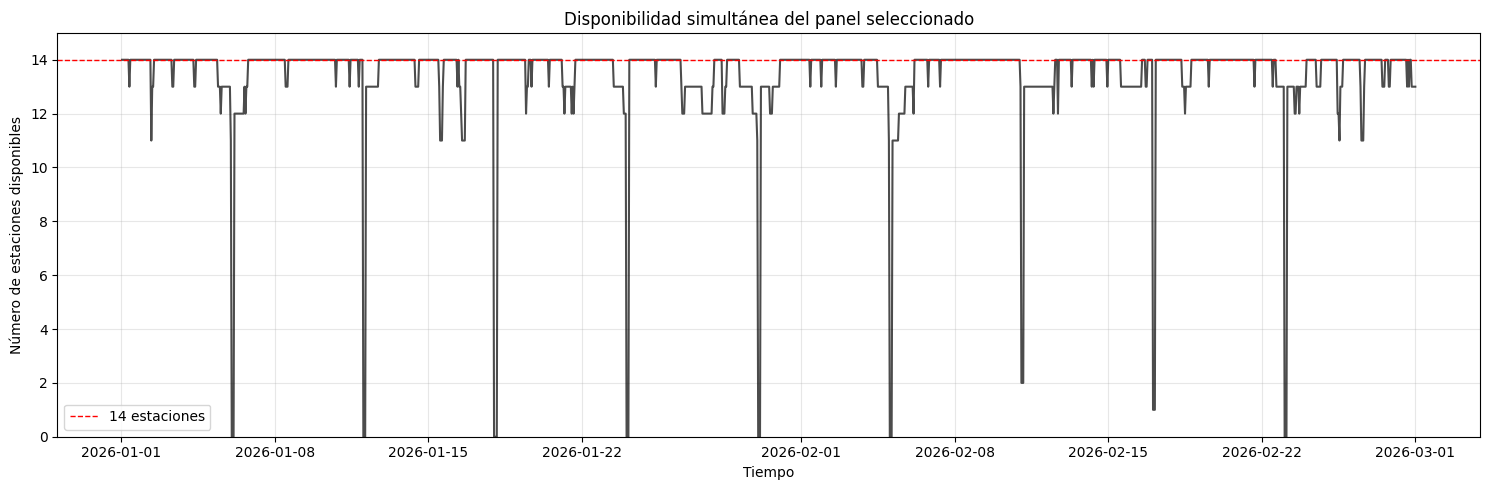

In [15]:
# Evolución temporal

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(
    disponibilidad_panel.index,
    disponibilidad_panel["n_disponibles"], color ='black', alpha=0.7
)

ax.axhline(len(estaciones_finales),linestyle="--",
    linewidth=1,label="14 estaciones", color='red'
)

ax.set_title("Disponibilidad simultánea del panel seleccionado")

ax.set_xlabel("Tiempo")
ax.set_ylabel("Número de estaciones disponibles")
ax.set_ylim(0,len(estaciones_finales) + 1)

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Identificación de interrupciones colectivas de la red

La selección de estaciones redujo considerablemente la proporción de valores faltantes, pero todavía existen horas en las que gran parte de la red deja de reportar simultáneamente.

Definiremos una hora de **baja disponibilidad** cuando

$$
P_t<50\%,
$$

donde $P_t$ es el porcentaje de las $14$ estaciones seleccionadas que presentan una medición válida en el instante $t$.

Los resultados anteriores muestran que existen $28$ horas que cumplen esta condición.

Estas horas no parecen distribuirse aleatoriamente. Por el contrario, se concentran en bloques de aproximadamente tres horas y aparecen en fechas específicas.

Para caracterizar este fenómeno agruparemos las horas consecutivas de baja disponibilidad en **episodios**.

Para cada episodio determinaremos:

- instante de inicio;
- instante final;
- duración;
- número mínimo de estaciones disponibles;
- porcentaje mínimo de disponibilidad.

También calcularemos el tiempo transcurrido entre inicios consecutivos para investigar si existe una estructura periódica.



### Conservación del calendario temporal

Por ahora no eliminaremos estas horas.

En su lugar, construiremos una variable indicadora

$$
B_t=
\begin{cases}
1, & P_t<50\%,\\
0, & P_t\geq50\%.
\end{cases}
$$

Esta variable permitirá conservar la secuencia horaria completa

$$
\Delta t=1\text{ hora}
$$

y, al mismo tiempo, identificar las observaciones correspondientes a periodos de baja confiabilidad de la red.

Posteriormente podremos decidir si estos periodos deben excluirse, conservarse o tratarse de manera especial dependiendo del análisis que se realice.

In [16]:
# Identificación de horas de baja disponibilidad

umbral_disponibilidad = 50

disponibilidad_panel["baja_disponibilidad"] = (
    disponibilidad_panel["porcentaje_disponible"]
    < umbral_disponibilidad
)


# Agrupación de horas consecutivas en episodios

grupos = (
    disponibilidad_panel["baja_disponibilidad"]
    .ne(
        disponibilidad_panel["baja_disponibilidad"].shift()
    )
    .cumsum()
)

episodios = []

for _, bloque in disponibilidad_panel[
    disponibilidad_panel["baja_disponibilidad"]
].groupby(
    grupos[disponibilidad_panel["baja_disponibilidad"]]
):

    episodios.append({
        "inicio": bloque.index.min(),
        "fin": bloque.index.max(),
        "duracion_horas": len(bloque),
        "min_estaciones": bloque["n_disponibles"].min(),
        "min_porcentaje": bloque["porcentaje_disponible"].min()
    })


episodios_red = pd.DataFrame(episodios)


# Tiempo entre episodios

episodios_red["horas_desde_anterior"] = (
    episodios_red["inicio"]
    .diff()
    .dt.total_seconds()
    / 3600
)

episodios_red["dias_desde_anterior"] = (
    episodios_red["horas_desde_anterior"]
    / 24
)

In [17]:
print("Número de episodios de baja disponibilidad:")
print(len(episodios_red))

print("\nEpisodios detectados:")

display(episodios_red.round(2))


print("\nDuración total de las horas de baja disponibilidad:")
print(episodios_red["duracion_horas"].sum(),"horas")


print("\nIntervalos entre inicios de episodios:")

display(episodios_red[["inicio","dias_desde_anterior"]])

Número de episodios de baja disponibilidad:
9

Episodios detectados:


,inicio,fin,duracion_horas,min_estaciones,min_porcentaje,horas_desde_anterior,dias_desde_anterior
0,2026-01-06 01:00:00,2026-01-06 03:00:00,3,0,0.00,NaN,NaN
1,2026-01-12 01:00:00,2026-01-12 03:00:00,3,0,0.00,144.0,6.00
2,2026-01-18 00:00:00,2026-01-18 03:00:00,4,0,0.00,143.0,5.96
3,2026-01-24 01:00:00,2026-01-24 03:00:00,3,0,0.00,145.0,6.04
4,2026-01-30 01:00:00,2026-01-30 03:00:00,3,0,0.00,144.0,6.00
5,2026-02-05 01:00:00,2026-02-05 03:00:00,3,0,0.00,144.0,6.00
6,2026-02-11 01:00:00,2026-02-11 03:00:00,3,2,14.29,144.0,6.00
7,2026-02-17 01:00:00,2026-02-17 03:00:00,3,1,7.14,144.0,6.00
8,2026-02-23 01:00:00,2026-02-23 03:00:00,3,0,0.00,144.0,6.00



Duración total de las horas de baja disponibilidad:
28 horas

Intervalos entre inicios de episodios:


,inicio,dias_desde_anterior
0,2026-01-06 01:00:00,NaN
1,2026-01-12 01:00:00,6.000000
2,2026-01-18 00:00:00,5.958333
3,2026-01-24 01:00:00,6.041667
4,2026-01-30 01:00:00,6.000000
5,2026-02-05 01:00:00,6.000000
6,2026-02-11 01:00:00,6.000000
7,2026-02-17 01:00:00,6.000000
8,2026-02-23 01:00:00,6.000000


## Imputación de los valores faltantes

Después de seleccionar las $14$ estaciones, el panel conserva únicamente un $4.34\%$ de valores faltantes.

El diagnóstico también mostró que existen dos tipos diferentes de ausencia de información:

1. faltantes individuales o pequeños huecos en una estación;
2. episodios de baja disponibilidad en los que muchas estaciones dejan de reportar simultáneamente.

Por esta razón utilizaremos una estrategia de imputación en dos etapas.

### 1. Interpolación temporal para huecos cortos

Para observaciones faltantes fuera de los episodios de baja disponibilidad utilizaremos interpolación temporal.

La idea consiste en estimar un valor intermedio utilizando las observaciones vecinas de la misma estación.

Limitaremos la interpolación a huecos pequeños para evitar reconstruir artificialmente interrupciones prolongadas.

### 2. Perfil horario para los valores restantes

Los valores que continúen faltantes se sustituirán utilizando la mediana de la misma estación para la misma hora del día:

$$
\widehat{X}_{i,t}
=
\operatorname{mediana}
\left\{
X_{i,s}:
\operatorname{hora}(s)=\operatorname{hora}(t)
\right\}.
$$

Esta estrategia aprovecha la estructura intradiaria del ozono y es robusta frente a valores elevados.

También conservaremos una máscara que indique cuáles valores fueron originalmente faltantes:

$$
I_{i,t}
=
\begin{cases}
1, & \text{si el valor fue imputado},\\
0, & \text{si corresponde a una medición original}.
\end{cases}
$$

El objetivo no es ocultar la ausencia de información, sino obtener un panel completo manteniendo la trazabilidad de las observaciones imputadas.

In [18]:
# Máscara de valores originalmente faltantes

mascara_imputados = o3_seleccionado.isna().copy()

print("Valores faltantes antes de imputar:")
print(mascara_imputados.sum().sum())



o3_imputado = o3_seleccionado.copy()


# ETAPA 1: Interpolación temporal de huecos cortos

interpolado = o3_seleccionado.interpolate(
    method="time",
    limit=3,
    limit_direction="both",
    limit_area="inside"
)

# No utilizaremos interpolación durante los episodios de baja disponibilidad de la red
horas_problematicas = (
    disponibilidad_panel["baja_disponibilidad"]
)

for estacion in estaciones_finales:

    usar_interpolacion = (
        o3_seleccionado[estacion].isna()
        & ~horas_problematicas
    )

    o3_imputado.loc[
        usar_interpolacion,
        estacion
    ] = interpolado.loc[
        usar_interpolacion,
        estacion
    ]


print("\nFaltantes después de la interpolación:")
print(o3_imputado.isna().sum().sum())


# ETAPA 2: Mediana de cada estación según la hora del día

for estacion in estaciones_finales:

    # Perfil horario calculado únicamente con datos originales
    mediana_horaria = (
        o3_seleccionado[estacion]
        .groupby(o3_seleccionado.index.hour)
        .median()
    )

    faltantes = o3_imputado[estacion].isna()

    horas = o3_imputado.index[faltantes].hour

    o3_imputado.loc[faltantes, estacion] = (
        horas.map(mediana_horaria)
    )



# Verificación 

print("\nFaltantes después de las dos etapas:")
print(o3_imputado.isna().sum().sum())

print("\nNúmero de valores originalmente faltantes:")
print(mascara_imputados.sum().sum())

print("\nPorcentaje de valores imputados:")
print(
    f"{100 * mascara_imputados.sum().sum() / o3_imputado.size:.2f}%"
)

print("\nDimensiones del panel:")
print(o3_imputado.shape)

print("\nFrecuencia temporal:")
print(pd.infer_freq(o3_imputado.index))

Valores faltantes antes de imputar:
860

Faltantes después de la interpolación:
639

Faltantes después de las dos etapas:
0

Número de valores originalmente faltantes:
860

Porcentaje de valores imputados:
4.34%

Dimensiones del panel:
(1416, 14)

Frecuencia temporal:
h


## Distribución de las concentraciones de ozono en las estaciones seleccionadas

Una vez construido el panel completo podemos comparar el comportamiento de las concentraciones de ozono entre estaciones.

Para cada estación analizaremos:

- mediana;
- rango intercuartílico;
- dispersión;
- concentraciones elevadas.

Utilizaremos diagramas de caja, ya que permiten comparar simultáneamente las distribuciones de las $14$ estaciones.

El rango intercuartílico se define como

$$
IQR = Q_3-Q_1,
$$

donde $Q_1$ y $Q_3$ representan los percentiles $25$ y $75$, respectivamente.

Los puntos alejados de la caja no deben interpretarse automáticamente como errores. En datos ambientales pueden corresponder a episodios reales de concentraciones elevadas.

Como únicamente el $4.34\%$ de las observaciones fueron imputadas, el comportamiento global de las distribuciones está determinado principalmente por las mediciones originales.

In [19]:
# Estadísticos descriptivos

resumen_o3 = (
    o3_imputado.describe().T
    .rename(columns={
        "count": "n",
        "mean": "media",
        "std": "desv_std",
        "min": "minimo",
        "25%": "q25",
        "50%": "mediana",
        "75%": "q75",
        "max": "maximo"
    })
)

resumen_o3["IQR"] = resumen_o3["q75"] - resumen_o3["q25"]

resumen_o3 = resumen_o3.sort_values("mediana", ascending=False)

print("Resumen de las concentraciones por estación:")
resumen_o3[["media","mediana","desv_std","q25","q75","IQR","maximo"]].round(2)

Resumen de las concentraciones por estación:


,media,mediana,desv_std,q25,q75,IQR,maximo
AJM,47.02,40.0,29.05,27.0,60.0,33.0,162.0
PED,36.51,28.0,30.43,13.0,53.0,40.0,148.0
INN,28.00,26.0,12.55,19.0,35.0,16.0,78.0
ATI,31.75,24.0,27.21,11.0,46.0,35.0,168.0
FAC,31.22,23.0,28.60,9.0,47.0,38.0,154.0
UAX,30.88,20.0,30.28,4.5,52.0,47.5,125.0
GAM,29.26,20.0,30.32,2.0,51.0,49.0,140.0
HGM,31.16,19.0,33.03,4.0,51.0,47.0,151.0
MGH,29.21,18.0,30.51,4.0,47.0,43.0,145.0
VIF,25.89,18.0,24.91,3.0,44.0,41.0,125.0


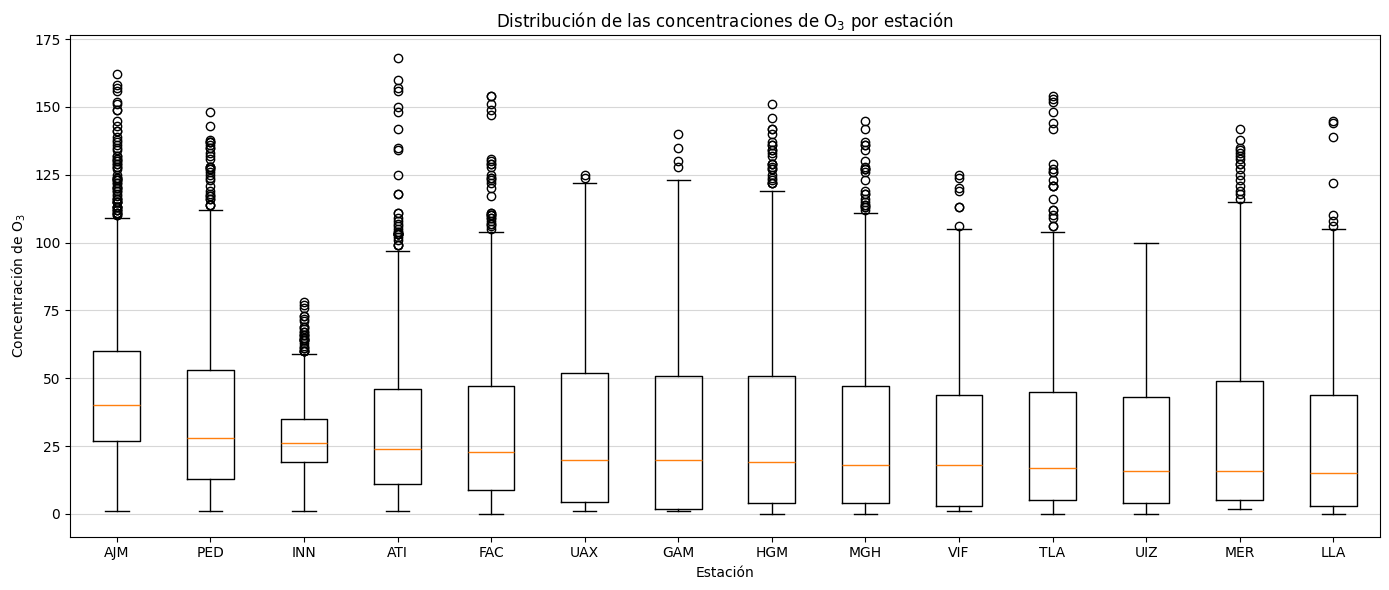

In [20]:
orden = resumen_o3.index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))

ax.boxplot([o3_imputado[e] for e in orden],
    tick_labels=orden,
    showfliers=True)

ax.set_title("Distribución de las concentraciones de O$_3$ por estación")
ax.set_xlabel("Estación")
ax.set_ylabel("Concentración de O$_3$")
ax.tick_params(axis="x")
ax.grid(axis="y",alpha=0.5)

plt.tight_layout()
plt.show()

## Patrón intradiario de las concentraciones de ozono

Las distribuciones anteriores resumen las concentraciones durante todo el periodo, pero no muestran cómo cambia el ozono a lo largo del día.

Para estudiar esta estructura agruparemos las observaciones según la hora

$$
h\in\{0,1,\ldots,23\}.
$$

Para cada estación calcularemos la mediana de las concentraciones registradas a una misma hora:

$$
M_i(h)
=
\operatorname{mediana}
\left\{
X_{i,t}:
\operatorname{hora}(t)=h
\right\}.
$$

Utilizamos la mediana porque las distribuciones presentan asimetría y concentraciones elevadas que pueden influir considerablemente sobre la media.

Esta representación permitirá identificar:

- horas con concentraciones típicamente bajas;
- periodo del día en el que aumenta el ozono;
- hora aproximada del máximo;
- diferencias en el ciclo diario entre estaciones.

El objetivo no es modelar todavía la estacionalidad diaria, sino comprobar visualmente que existe una estructura temporal que podrá utilizarse posteriormente para construir variables como rezagos, ventanas móviles y características horarias.

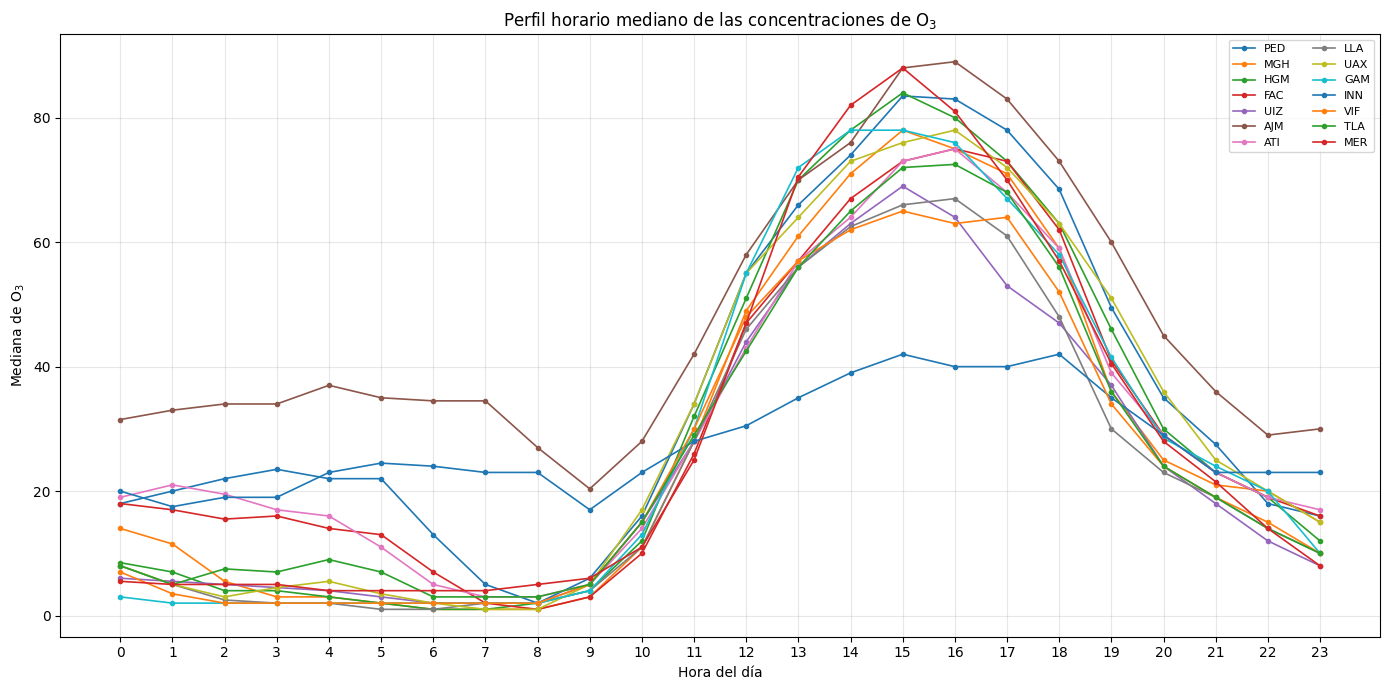

In [21]:
# Perfil horario mediano

perfil_horario = (
    o3_imputado
    .groupby(o3_imputado.index.hour)
    .median()
)

perfil_horario.index.name = "hora"


fig, ax = plt.subplots(figsize=(14, 7))

for estacion in estaciones_finales:

    ax.plot(
        perfil_horario.index,
        perfil_horario[estacion],
        marker="o",
        markersize=3,
        linewidth=1.2,
        label=estacion
    )

ax.set_title(
    "Perfil horario mediano de las concentraciones de O$_3$"
)

ax.set_xlabel("Hora del día")
ax.set_ylabel("Mediana de O$_3$")

ax.set_xticks(range(24))

ax.grid(alpha=0.3)

ax.legend(
    ncol=2,
    fontsize=8
)

plt.tight_layout()
plt.show()

In [22]:
# Hora del máximo típico por estación

resumen_horario = pd.DataFrame({
    "hora_maxima": perfil_horario.idxmax(),
    "valor_mediano_maximo": perfil_horario.max()
})

print("Hora del máximo mediano por estación:")
resumen_horario.sort_values("hora_maxima").round(2)

Hora del máximo mediano por estación:


,hora_maxima,valor_mediano_maximo
GAM,14,78.0
PED,15,83.5
MGH,15,78.0
HGM,15,84.0
UIZ,15,69.0
INN,15,42.0
VIF,15,65.0
MER,15,88.0
FAC,16,75.0
AJM,16,89.0


## Evolución diaria de las concentraciones de ozono

Las observaciones originales tienen frecuencia horaria. Para visualizar de manera más clara la evolución temporal de las concentraciones podemos reducir la frecuencia y calcular el promedio diario de cada estación.

Para una estación $i$ y un día $d$, definimos

$$
\bar{X}_{i,d}
=
\frac{1}{n_{i,d}}
\sum_{t\in d}X_{i,t},
$$

donde $n_{i,d}$ es el número de observaciones horarias correspondientes al día $d$.

Como el panel ya fue imputado, cada día dispone de las observaciones necesarias para calcular el promedio.

### Ajuste de la convención horaria

En la base original las horas están codificadas de $1$ a $24$.

Por ejemplo,

$$
\text{FECHA}=2026\text{-}01\text{-}01,
\qquad
\text{HORA}=24
$$

fue representada temporalmente como

$$
2026\text{-}01\text{-}02\ 00{:}00.
$$

Para que las 24 observaciones vuelvan a asociarse con el día reportado originalmente, desplazaremos el índice una hora hacia atrás antes de realizar la agregación diaria.

De esta manera, cada promedio diario se calcula a partir de las 24 horas originalmente asignadas a ese día.

In [23]:
# Promedio diario por estación

# Desplazamos una hora para recuperar la convención original de días con horas 1,...,24
o3_para_diario = o3_imputado.copy()

o3_para_diario.index = o3_para_diario.index - pd.Timedelta(hours=1)

# Promedio diario
o3_diario = o3_para_diario.resample("D").mean()


print("Dimensiones de la base horaria:")
print(o3_imputado.shape)

print("\nDimensiones de la base diaria:")
print(o3_diario.shape)

print("\nPeriodo:")
print(
    o3_diario.index.min(),
    "a",
    o3_diario.index.max()
)

print("\nPrimeros promedios diarios:")
display(o3_diario.head())

Dimensiones de la base horaria:
(1416, 14)

Dimensiones de la base diaria:
(59, 14)

Periodo:
2026-01-01 00:00:00 a 2026-02-28 00:00:00

Primeros promedios diarios:


,PED,MGH,HGM,FAC,UIZ,AJM,ATI,LLA,UAX,GAM,INN,VIF,TLA,MER
timestamp,,,,,,,,,,,,,,
2026-01-01,38.125000,33.916667,31.166667,34.708333,29.500000,52.416667,33.125000,23.791667,32.791667,32.791667,28.083333,27.250000,32.458333,31.125000
2026-01-02,43.625000,31.875000,28.708333,28.708333,28.416667,58.000000,31.208333,22.250000,33.208333,34.166667,31.791667,22.833333,26.166667,32.270833
2026-01-03,38.791667,31.541667,31.250000,33.083333,25.333333,52.750000,31.875000,24.687500,32.666667,29.500000,37.041667,28.125000,30.625000,29.333333
2026-01-04,43.791667,34.166667,36.125000,34.708333,28.750000,56.750000,37.875000,26.041667,33.625000,35.166667,38.625000,25.916667,32.500000,32.916667
2026-01-05,53.875000,37.708333,33.708333,35.833333,31.291667,70.125000,43.375000,26.333333,28.397849,33.125000,39.791667,27.104167,34.916667,31.991667


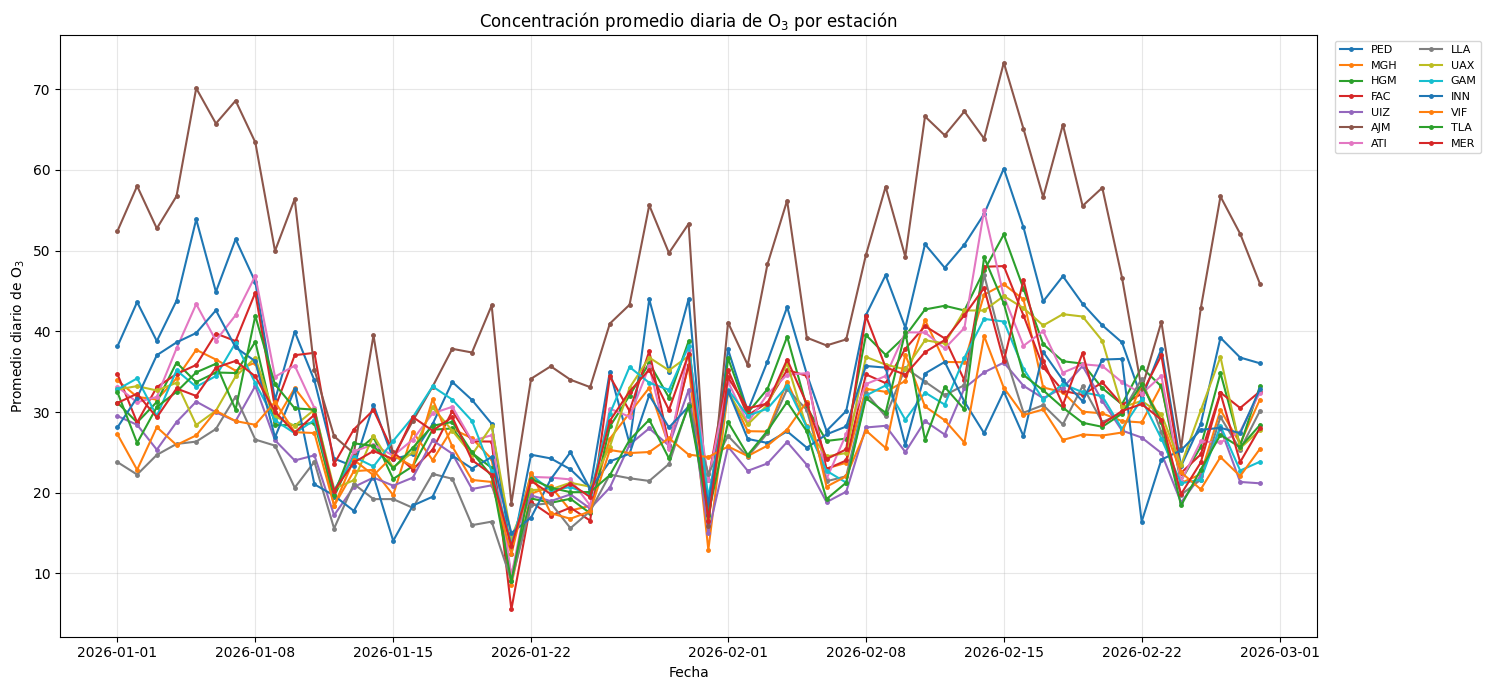

In [24]:
fig, ax = plt.subplots(figsize=(15, 7))

for estacion in estaciones_finales:

    ax.plot(
        o3_diario.index,
        o3_diario[estacion],
        linewidth=1.5,
        marker="o",
        markersize=2.5,
        label=estacion)


ax.set_title("Concentración promedio diaria de O$_3$ por estación")

ax.set_xlabel("Fecha")
ax.set_ylabel("Promedio diario de O$_3$")
ax.grid(alpha=0.3)
ax.legend(
    ncol=2,
    fontsize=8,
    bbox_to_anchor=(1.01, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## Promedio diario de ozono de la red seleccionada

Para resumir el comportamiento global de las estaciones seleccionadas podemos calcular, para cada día, el promedio de las concentraciones medias diarias de las $14$ estaciones.

Si $\bar{X}_{i,d}$ representa el promedio diario de la estación $i$ en el día $d$, definimos

$$
\bar{X}_d=
\frac{1}{N}
\sum_{i=1}^{N}\bar{X}_{i,d},
$$

donde $N=14$ es el número de estaciones seleccionadas.

Esta serie proporciona una medida agregada del comportamiento diario de la red de monitoreo.

Debe interpretarse como un resumen de las estaciones incluidas en el panel, y no como una concentración espacialmente representativa de toda la ciudad, ya que todas las estaciones reciben el mismo peso.

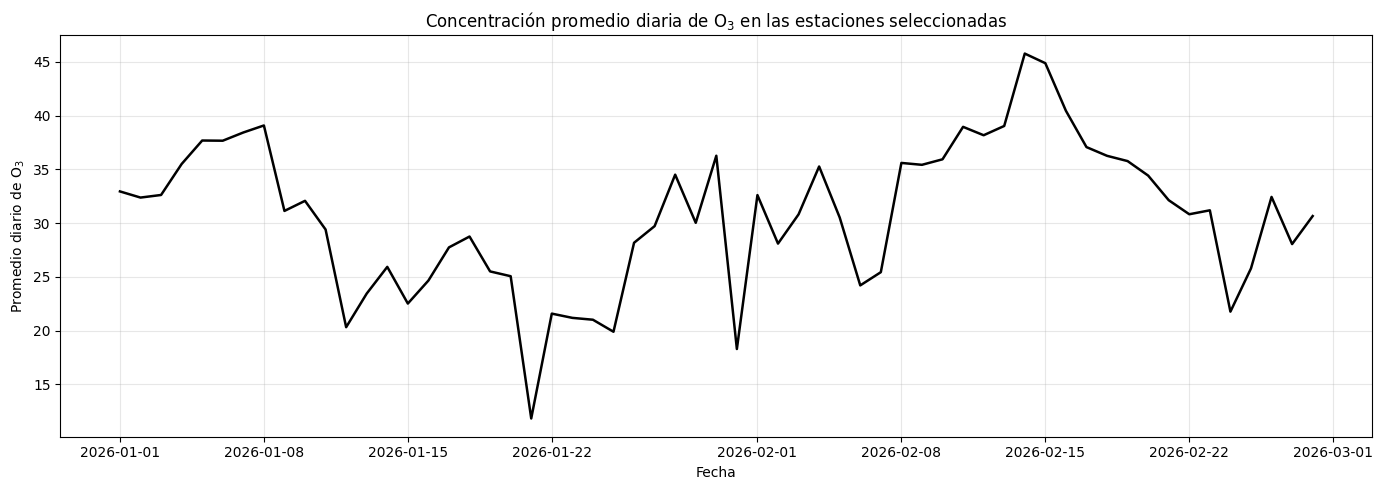

In [25]:
# Promedio diario de todas las estaciones

promedio_diario_red = o3_diario.mean(axis=1)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    promedio_diario_red.index,
    promedio_diario_red,
    markersize=4,
    linewidth=1.8, color = 'black'
)

ax.set_title("Concentración promedio diaria de O$_3$ en las estaciones seleccionadas")
ax.set_xlabel("Fecha")
ax.set_ylabel("Promedio diario de O$_3$")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
print("Resumen del promedio diario de la red:")
display(promedio_diario_red.describe().round(2).to_frame("o3_promedio_diario"))

print("\nDía con mayor promedio:")
print(promedio_diario_red.idxmax())

print("Valor:")
print(round(promedio_diario_red.max(), 2))

print("\nDía con menor promedio:")
print(promedio_diario_red.idxmin())

print("Valor:")
print(round(promedio_diario_red.min(), 2))

Resumen del promedio diario de la red:


,o3_promedio_diario
count,59.00
mean,30.72
std,6.82
min,11.81
25%,25.64
50%,31.13
75%,35.68
max,45.78



Día con mayor promedio:
2026-02-14 00:00:00
Valor:
45.78

Día con menor promedio:
2026-01-21 00:00:00
Valor:
11.81


## Construcción del panel analítico final

Después del proceso de limpieza y selección contamos con:

- $14$ estaciones;
- $1416$ observaciones horarias;
- frecuencia temporal regular de una hora;
- valores faltantes imputados;
- identificación de las observaciones que fueron imputadas;
- identificación de los periodos de baja disponibilidad de la red.

Transformaremos ahora la matriz en formato ancho a un **panel en formato largo**.

Cada observación representará una combinación

$$
(i,t),
$$

donde $i$ identifica una estación y $t$ un instante temporal.

El panel contendrá las siguientes variables:

- `timestamp`: instante temporal utilizado para el análisis;
- `fecha`: día correspondiente a la convención original de la base;
- `hora`: hora original, codificada de $1$ a $24$;
- `estacion`: identificador de la estación;
- `o3`: concentración final de ozono;
- `imputado`: indica si la observación fue originalmente faltante;
- `baja_disponibilidad`: indica si la hora pertenece a un episodio de baja disponibilidad colectiva.

El número esperado de filas será

$$
1416\times14=19\,824.
$$

Este archivo será el punto de partida para las siguientes etapas del curso, donde construiremos rezagos, diferencias, ventanas móviles y otras características temporales.

In [27]:
# Panel de concentraciones de O3

panel_o3 = (
    o3_imputado
    .reset_index()
    .melt(
        id_vars="timestamp",
        var_name="estacion",
        value_name="o3"
    )
)


# Indicador de valores imputados

panel_imp = (
    mascara_imputados
    .reset_index()
    .melt(
        id_vars="timestamp",
        var_name="estacion",
        value_name="imputado"
    )
)


# Integración

panel_final = panel_o3.merge(
    panel_imp,
    on=["timestamp", "estacion"],
    how="left"
)


# Bandera de baja disponibilidad de la red

panel_final["baja_disponibilidad"] = (
    panel_final["timestamp"]
    .map(
        disponibilidad_panel["baja_disponibilidad"]
    )
)


# Recuperamos la convención temporal original
# FECHA + HORA = 1,...,24

tiempo_fuente = (
    panel_final["timestamp"]
    - pd.Timedelta(hours=1)
)

panel_final["fecha"] = (
    tiempo_fuente.dt.normalize()
)

panel_final["hora"] = (
    ((panel_final["timestamp"].dt.hour - 1) % 24) + 1
)


# Reordenamos columnas

panel_final = panel_final[
    [
        "timestamp",
        "fecha",
        "hora",
        "estacion",
        "o3",
        "imputado",
        "baja_disponibilidad"
    ]
]


# Orden estación-tiempo
panel_final = (
    panel_final
    .sort_values(
        ["estacion", "timestamp"]
    )
    .reset_index(drop=True)
)


print("Dimensiones del panel final:")
print(panel_final.shape)

print("\nNúmero de estaciones:")
print(panel_final["estacion"].nunique())

print("\nNúmero de instantes temporales:")
print(panel_final["timestamp"].nunique())

print("\nValores faltantes en O3:")
print(panel_final["o3"].isna().sum())

print("\nObservaciones imputadas:")
print(panel_final["imputado"].sum())

print("\nObservaciones en periodos de baja disponibilidad:")
print(panel_final["baja_disponibilidad"].sum())

print("\nCombinaciones estación-timestamp duplicadas:")
print(panel_final.duplicated(subset=["estacion", "timestamp"]).sum())

Dimensiones del panel final:
(19824, 7)

Número de estaciones:
14

Número de instantes temporales:
1416

Valores faltantes en O3:
0

Observaciones imputadas:
860

Observaciones en periodos de baja disponibilidad:
392

Combinaciones estación-timestamp duplicadas:
0


In [28]:
print("\nPrimeras observaciones:")
display(panel_final.head(15))


# Guardado
nombre_archivo = "panel_o3_2026.csv"

panel_final.to_csv(
    nombre_archivo,
    index=False
)

print("\nPanel guardado como:")
print(nombre_archivo)


Primeras observaciones:


,timestamp,fecha,hora,estacion,o3,imputado,baja_disponibilidad
0,2026-01-01 01:00:00,2026-01-01,1,AJM,19.0,False,False
1,2026-01-01 02:00:00,2026-01-01,2,AJM,23.0,False,False
2,2026-01-01 03:00:00,2026-01-01,3,AJM,30.0,False,False
3,2026-01-01 04:00:00,2026-01-01,4,AJM,34.0,False,False
4,2026-01-01 05:00:00,2026-01-01,5,AJM,36.0,False,False
5,2026-01-01 06:00:00,2026-01-01,6,AJM,38.0,False,False
6,2026-01-01 07:00:00,2026-01-01,7,AJM,37.0,False,False
7,2026-01-01 08:00:00,2026-01-01,8,AJM,35.0,False,False
8,2026-01-01 09:00:00,2026-01-01,9,AJM,37.0,True,False
9,2026-01-01 10:00:00,2026-01-01,10,AJM,39.0,False,False



Panel guardado como:
panel_o3_2026.csv


# Tarea 1. Construcción de un panel de calidad del aire para 2025


datos: https://aire.cdmx.gob.mx/default.php?opc=%27aKBh%27

## Objetivo

El objetivo de esta actividad es reproducir, de manera independiente, el procedimiento desarrollado en clase para construir un panel temporal de calidad del aire a partir de datos reales.

Cada estudiante deberá descargar los datos correspondientes al año **2025** de la Red Automática de Monitoreo Atmosférico (RAMA) de la Ciudad de México y seleccionar **un contaminante de su preferencia**.

Entre los archivos disponibles se encuentran contaminantes como:

- CO;
- NO;
- NO$_2$;
- NO$_x$;
- O$_3$;
- PM$_{10}$;
- PM$_{2.5}$;
- SO$_2$.



## Fuente de datos

Los datos deben descargarse directamente de la página oficial de Calidad del Aire de la Ciudad de México:

**Datos $\rightarrow$ Excel $\rightarrow$ Bases de datos - Red Automática de Monitoreo Atmosférico (RAMA)**

Seleccionar el año **2025**, descargar el archivo correspondiente y utilizar el contaminante elegido.



## Actividades

A partir del archivo seleccionado, elaborar un notebook en Jupyter que reproduzca el procedimiento realizado en clase.

### 1. Preparación de los datos

- cargar la base;
- identificar las estaciones disponibles;
- sustituir los valores `-99` por `NaN`;
- construir la variable `timestamp` a partir de `FECHA` y `HORA`;
- verificar:
  - primer y último instante;
  - número de observaciones;
  - duplicados;
  - frecuencia temporal;
  - regularidad horaria.

### 2. Diagnóstico de calidad por estación

Para cada estación calcular:

- número de observaciones esperadas;
- observaciones disponibles;
- valores faltantes;
- porcentaje de cobertura;
- número de huecos temporales;
- longitud del hueco máximo en horas y días.

Utilizar como criterios iniciales de selección:

$$
\text{cobertura}\geq90\%
$$

y

$$
\text{hueco máximo}\leq48\text{ horas}.
$$

Mostrar gráficamente la cobertura de las estaciones y justificar cuáles serán conservadas para el análisis.

### 3. Disponibilidad simultánea de la red

Para las estaciones seleccionadas calcular, en cada instante,

$$
P_t=
\frac{\text{número de estaciones disponibles en }t}
{\text{número de estaciones seleccionadas}}
\times100.
$$

Identificar los periodos de baja disponibilidad utilizando

$$
P_t<50\%.
$$

Determinar:

- número de episodios;
- inicio y final de cada episodio;
- duración;
- número mínimo de estaciones disponibles.

### 4. Imputación

Aplicar el procedimiento utilizado en clase:

1. interpolación temporal para huecos cortos;
2. mediana de la estación para la misma hora del día para los valores faltantes restantes.

Conservar una variable que permita identificar qué observaciones fueron imputadas.

### 5. Análisis exploratorio

Realizar al menos las siguientes visualizaciones:

- distribución del contaminante por estación mediante diagramas de caja;
- perfil horario mediano;
- promedio diario por estación;
- promedio diario considerando conjuntamente todas las estaciones seleccionadas.

Cada figura deberá incluir una **breve interpretación** de los resultados observados.

### 6. Construcción del panel final

Transformar los datos a formato largo, con una estructura similar a:

| timestamp | fecha | hora | estacion | contaminante | imputado | baja_disponibilidad |
|---|---|---:|---|---:|---|---|

El panel deberá contener una observación por combinación

$$
(\text{estación},t).
$$

Verificar que:

- no existan combinaciones estación--tiempo duplicadas;
- no existan valores faltantes en la variable del contaminante;
- se conserve la frecuencia horaria;
- las observaciones imputadas puedan identificarse.

Guardar el resultado en formato `.csv`.



## Entrega

Entregar:

1. el notebook `.ipynb` completamente ejecutado;
2. el archivo `.csv` correspondiente al panel final.

El notebook debe incluir celdas Markdown que expliquen brevemente:

- qué se está haciendo;
- por qué se realiza;
- cómo se interpretan los principales resultados.



## Importante

No se busca obtener exactamente el mismo número de estaciones que en el ejemplo de O$_3$.

El número de estaciones seleccionadas dependerá del contaminante elegido y de la calidad de sus datos durante 2025.

Lo importante es **aplicar correctamente los criterios, justificar las decisiones y construir un panel reproducible y listo para análisis posteriores**.